Saving Loan Risk Detector1.csv to Loan Risk Detector1 (1).csv


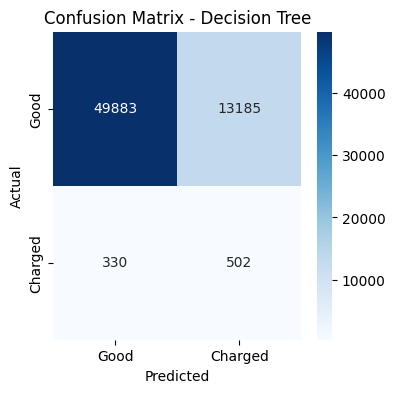

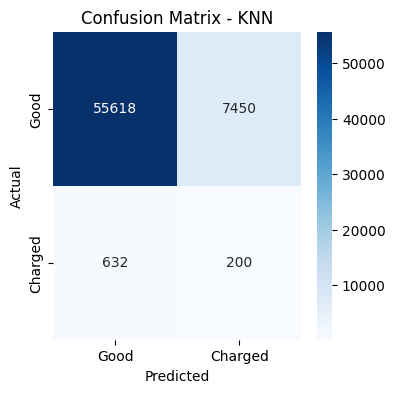

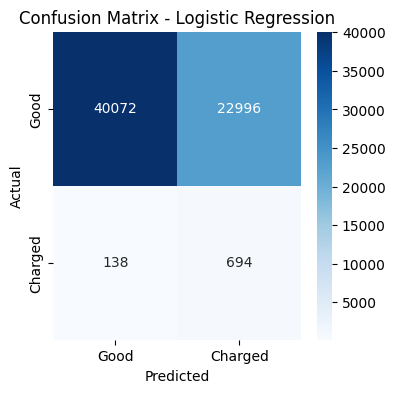

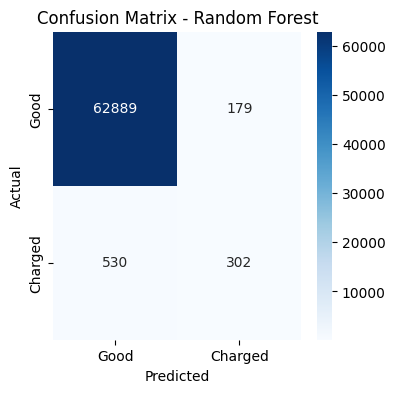

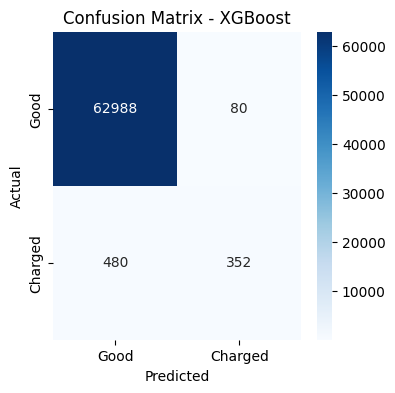

                 Model  Accuracy  Precision    Recall  F1 Score   ROC-AUC
4              XGBoost  0.991236   0.814815  0.423077  0.556962  0.850800
3        Random Forest  0.988905   0.627859  0.362981  0.460015  0.828865
0        Decision Tree  0.788498   0.036677  0.603365  0.069151  0.762019
2  Logistic Regression  0.637966   0.029295  0.834135  0.056602  0.791478
1                  KNN  0.873521   0.026144  0.240385  0.047159  0.572765


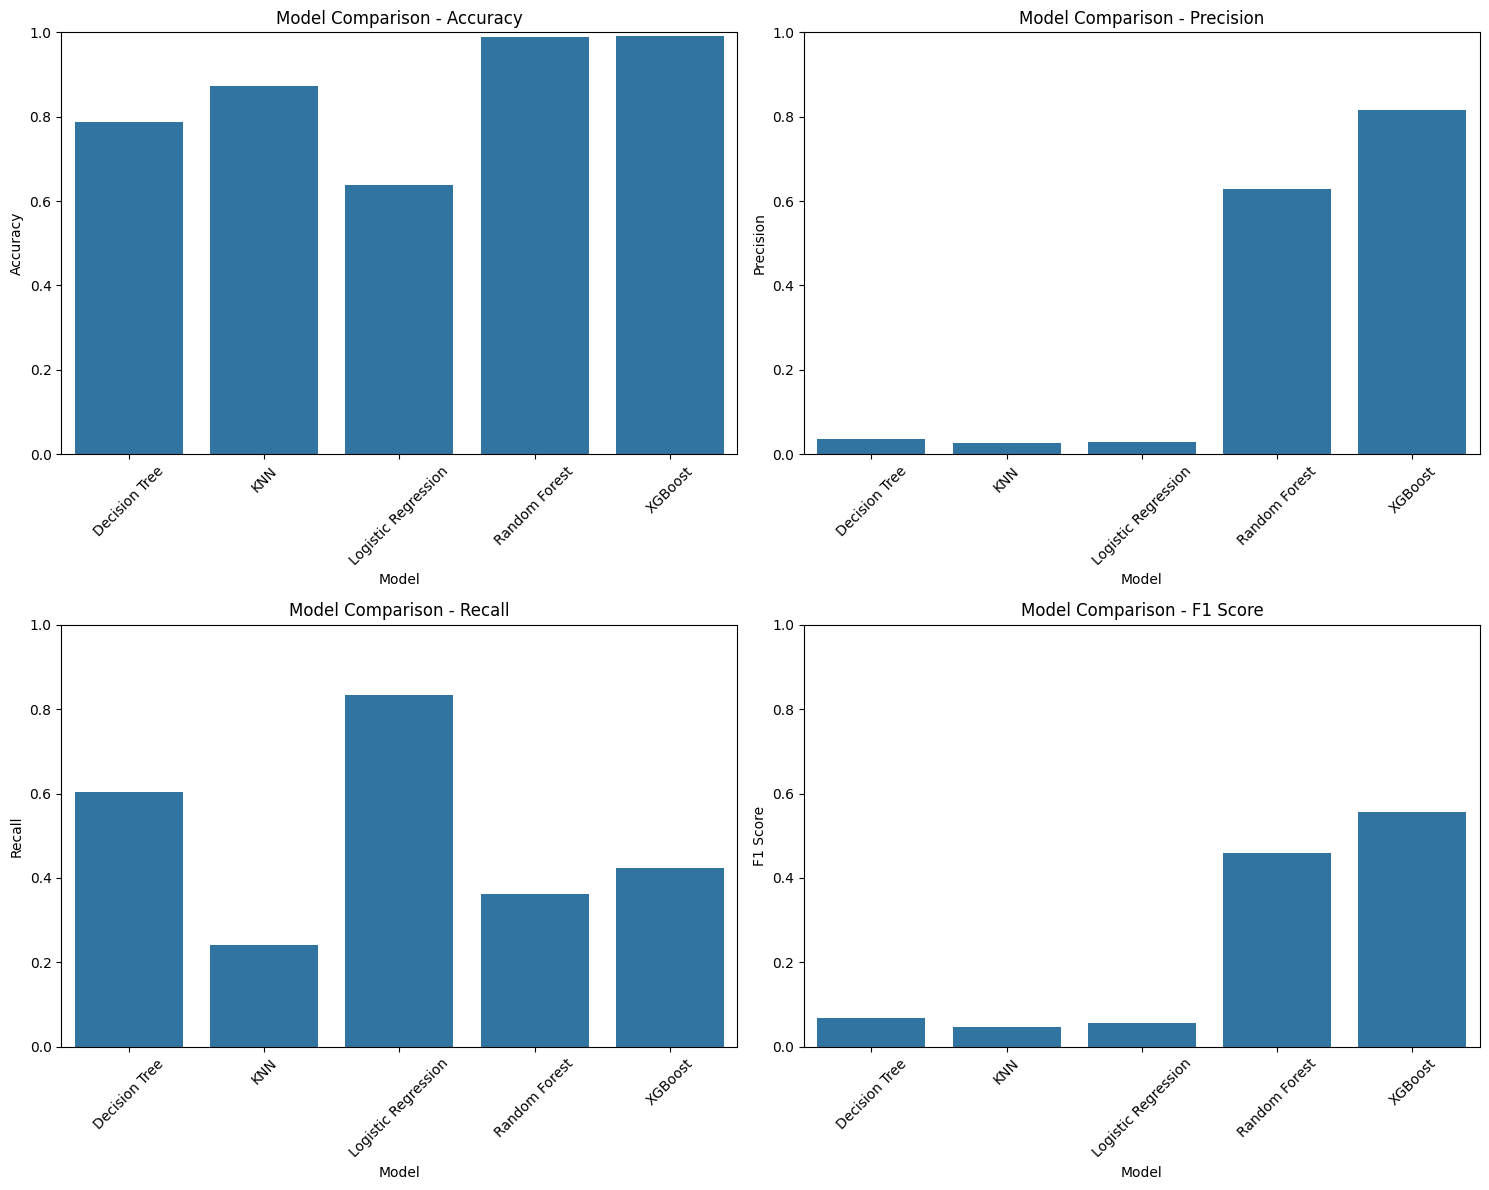

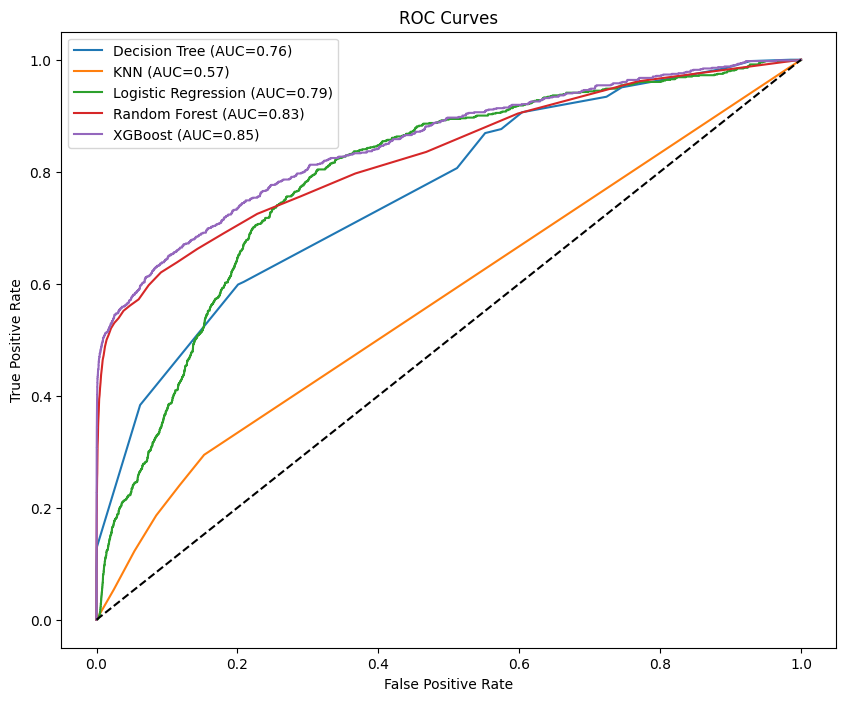

In [ ]:
# ✅ Full pipeline for Loan Risk Detector1.csv

# Step 1: Import Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import LabelEncoder, MinMaxScaler
from sklearn.model_selection import train_test_split, GridSearchCV, cross_val_score
from imblearn.over_sampling import ADASYN
from sklearn.ensemble import RandomForestClassifier
from sklearn.tree import DecisionTreeClassifier
from xgboost import XGBClassifier
from sklearn.neighbors import KNeighborsClassifier
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix, classification_report
import os

# Step 2: Load dataset
from google.colab import files
uploaded = files.upload()
file_path = list(uploaded.keys())[0]
df = pd.read_csv(file_path)

# Step 3: Drop leakage columns
leakage_cols = ['issue_d', 'earliest_cr_line', 'last_pymnt_d', 'next_pymnt_d', 'last_credit_pull_d',
                'recoveries', 'total_pymnt', 'total_rec_prncp', 'total_rec_int', 'total_rec_late_fee',
                'last_pymnt_amnt', 'collection_recovery_fee', 'out_prncp']
df = df.drop(leakage_cols, axis=1, errors='ignore')

# Step 4: Handle missing values
for col in df.columns:
    if df[col].dtype in ['int64', 'float64']:
        df[col] = df[col].fillna(df[col].median())
    elif df[col].dtype == 'object':
        df[col] = df[col].fillna(df[col].mode()[0])

# Step 5: Convert loan_status
df['loan_status'] = df['loan_status'].apply(lambda x: 1 if x in ['Charged Off', 'Default'] else 0)

# Step 6: Encode categorical columns
cat_cols = df.select_dtypes(include='object').columns.tolist()
ordinal = ['grade', 'sub_grade', 'emp_length']
nominal = [col for col in cat_cols if col not in ordinal + ['id', 'member_id']]
le = LabelEncoder()
for col in ordinal:
    if col in df.columns:
        df[col] = le.fit_transform(df[col].astype(str))
high_card_cols = [col for col in nominal if df[col].nunique() > 50]
df.drop(high_card_cols, axis=1, inplace=True, errors='ignore')
df = pd.get_dummies(df, columns=[col for col in nominal if col not in high_card_cols], drop_first=True)

# Step 7: Drop unnecessary IDs
df = df.drop(['id', 'member_id'], axis=1, errors='ignore')

# Step 8: Feature importance filter
X_temp = df.drop('loan_status', axis=1)
y_temp = df['loan_status']
rf_temp = RandomForestClassifier(random_state=42)
rf_temp.fit(X_temp, y_temp)
imp = pd.DataFrame({'feature': X_temp.columns, 'importance': rf_temp.feature_importances_})
low_imp = imp[imp['importance'] < 0.01]['feature'].tolist()
df = df.drop(low_imp, axis=1)

# Step 9: Split and Scale
X = df.drop('loan_status', axis=1)
y = df['loan_status']
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, stratify=y, random_state=42)
num_cols = X.select_dtypes(include=['int64', 'float64']).columns
scaler = MinMaxScaler()
X_train[num_cols] = scaler.fit_transform(X_train[num_cols])
X_test[num_cols] = scaler.transform(X_test[num_cols])

# Step 10: Resample using ADASYN
adasyn = ADASYN(sampling_strategy=0.5, random_state=42)
X_train_res, y_train_res = adasyn.fit_resample(X_train, y_train)

# Step 11: Define Models and Tune
from sklearn.model_selection import GridSearchCV
models = {
    "Decision Tree": DecisionTreeClassifier(max_depth=5, random_state=42),
    "KNN": KNeighborsClassifier(),
    "Logistic Regression": LogisticRegression(random_state=42, max_iter=1000)
}

# Random Forest tuning
rf_grid = {
    'n_estimators': [50, 100],
    'max_depth': [5, 10, None]
}
grid_rf = GridSearchCV(RandomForestClassifier(random_state=42), rf_grid, cv=5, scoring='f1')
grid_rf.fit(X_train_res, y_train_res)
models["Random Forest"] = grid_rf.best_estimator_

# XGBoost tuning
xgb_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 6]
}
grid_xgb = GridSearchCV(XGBClassifier(random_state=42, eval_metric='logloss'), xgb_grid, cv=5, scoring='f1')
grid_xgb.fit(X_train_res, y_train_res)
models["XGBoost"] = grid_xgb.best_estimator_

# Step 12: Evaluate models
from sklearn.metrics import roc_auc_score, roc_curve
import matplotlib.pyplot as plt
import seaborn as sns

results = []
threshold = 0.3
for name, model in models.items():
    model.fit(X_train_res, y_train_res)
    y_proba = model.predict_proba(X_test)[:, 1] if hasattr(model, 'predict_proba') else [0] * len(y_test)
    y_pred = (np.array(y_proba) > threshold).astype(int)

    results.append({
        'Model': name,
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1 Score': f1_score(y_test, y_pred),
        'ROC-AUC': roc_auc_score(y_test, y_proba) if hasattr(model, 'predict_proba') else None
    })

    # Confusion Matrix
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(4, 4))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
                xticklabels=['Good', 'Charged'], yticklabels=['Good', 'Charged'])
    plt.title(f'Confusion Matrix - {name}')
    plt.xlabel("Predicted")
    plt.ylabel("Actual")
    plt.show()

# Step 13: Display Metrics
result_df = pd.DataFrame(results)
result_df['ROC-AUC'] = result_df['ROC-AUC'].fillna('N/A')
print(result_df.sort_values(by='F1 Score', ascending=False))

# Step 14: Plot Metrics
plt.figure(figsize=(15, 12))
for i, metric in enumerate(['Accuracy', 'Precision', 'Recall', 'F1 Score']):
    plt.subplot(2, 2, i+1)
    sns.barplot(x='Model', y=metric, data=result_df)
    plt.title(f'Model Comparison - {metric}')
    plt.ylim(0, 1)
    plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

# Step 15: ROC Curve
plt.figure(figsize=(10, 8))
for name, model in models.items():
    if hasattr(model, "predict_proba"):
        y_proba = model.predict_proba(X_test)[:, 1]
        fpr, tpr, _ = roc_curve(y_test, y_proba)
        auc = roc_auc_score(y_test, y_proba)
        plt.plot(fpr, tpr, label=f'{name} (AUC={auc:.2f})')
plt.plot([0, 1], [0, 1], 'k--')
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curves")
plt.legend()
plt.show()
